In [1]:
# sys.path manipulation to include parent directory
import sys
from pathlib import Path

parent_folder = str(Path.cwd().parent)
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

# Importing necessary libraries and modules
import pandas as pd
from src.config import ApplicationConfig

# Import the custom visualization module
from src.data_plotter import DataPlotter

In [2]:
raw_df = pd.read_csv(ApplicationConfig().data_path)
display(raw_df.head())

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,"44,2352","47,6573","46,4418","64,8203","66,4545","44,4832",False
1,2,2,4,"60,8072","63,1721","62,0060","80,7144","81,2464","60,2287",False
2,3,2,1,"79,0275","83,0322","82,6421","98,2544","98,7852","80,9935",False
3,4,2,3,"79,7162","100,5086","122,3623","121,3634","118,6525","80,3156",False
4,5,2,5,"39,9891","51,7648","42,5143","61,0379","50,7165","64,2452",False


# Dataset overview

Before diving into data analysis, it is important to understand and document the dataset’s variables. This step supports a clearer understanding of the problem and aids in defining the data schema when working with databases. Additionally, it guides the exploratory analysis by clarifying the meaning and interpretation of each variable.

Briefly, the dataset represents the monitoring of a Floating Production Storage and Offloading (FPSO) equipment unit across a sequence of operational cycles, with the goal of identifying and predicting equipment failures. It includes setup configurations, sensor readings such as temperature, pressure, and frequency, as well as a target variable indicating whether the equipment was in a failure state.

| Variable          | Type          | Data Type |Interpretation                                                                  |
| ----------------- | ------------- | --------- |------------------------------------------------------------------------------- |
| Cycle             | Temporal      | Numeric (int) |Represents the passage of time in operational cycles |
| Preset\_1         | Setup | Categorical (int) | Operational configuration parameter of the equipment                      |
| Preset\_2         | Setup | Categorical (int) |Operational configuration parameter of the equipment                                                         |
| Temperature       | Sensor        | Numeric (float) |Temperature measured in a given operation cycle                        |
| Vibrations\_X/Y/Z | Sensor        | Numeric (float) |Vibration measurements along the three spatial axes in a given operation cycle                            |
| Frequency         | Sensor        | Numeric (float) |Frequency measured in a given operation cycle                             |
| Fail              | Target        | Binary (bool) |Indicates whether the equipment is in a failure state (True) or normal (False)         |


Inspecting the raw dataset, it is possible to verify that the columns data types are not properly defined.

In [3]:
# Displaying the data types of the DataFrame
raw_df.dtypes

Cycle           int64
Preset_1        int64
Preset_2        int64
Temperature    object
Pressure       object
VibrationX     object
VibrationY     object
VibrationZ     object
Frequency      object
Fail             bool
dtype: object

# Pre-processing

## Adjusting columns dtypes

The float numeric columns are being interpreted as text because they use commas as decimal separators. To ensure proper numerical analysis in Python, these commas should be replaced with dots, and the columns should be converted to float data types.

In [4]:
# Function to convert object columns with commas to float
def parse_comma_decimal_series(series: pd.Series) -> pd.Series:
    return series.str.replace(',', '.').astype('float64')

# Function to get object columns with commas in their values
def find_comma_decimal_columns(df: pd.DataFrame) -> list:
    """
    Returns a list of columns that contain commas in their values.
    """
    return [
        col for col in df.columns
        if df[col].dtype == 'object' and df[col].str.contains(',').any()
    ]

def df_convert_comma_decimals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adjusts the data types of columns in the DataFrame.
    Converts object columns with commas to float.
    """
    obj_columns = find_comma_decimal_columns(df)
    for col in obj_columns:
        df[col] = parse_comma_decimal_series(df[col])
    return df

In [5]:
obj_columns = find_comma_decimal_columns(raw_df)
print(f"Columns with commas: {obj_columns}")

Columns with commas: ['Temperature', 'Pressure', 'VibrationX', 'VibrationY', 'VibrationZ', 'Frequency']


In [6]:
# Applying the conversion function to the DataFrame
df = df_convert_comma_decimals(raw_df)

In [7]:
# New data types of the DataFrame
print(df.dtypes)
display(df.head())

Cycle            int64
Preset_1         int64
Preset_2         int64
Temperature    float64
Pressure       float64
VibrationX     float64
VibrationY     float64
VibrationZ     float64
Frequency      float64
Fail              bool
dtype: object


,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False
1,2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False
2,3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False
3,4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False
4,5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False


## Null values and index

In [8]:
# Checking for null values in the DataFrame
df.isnull().sum()

Cycle          0
Preset_1       0
Preset_2       0
Temperature    0
Pressure       0
VibrationX     0
VibrationY     0
VibrationZ     0
Frequency      0
Fail           0
dtype: int64

In [9]:
# Define Cycle as the index
df.set_index('Cycle', inplace=True)

With the data types defined, it is now possible to analyze the general statistics of the dataset.

# Descriptive statistics

In this step, the main goal is to perform an initial examination of the dataset to understand the overall behavior of the variables. This may reveal general patterns, potential anomalies, and relationships between the equipment setup parameters and sensor measurements. It may also provide early insights into possible causes of equipment failures in the FPSO system.

## Categorical variables

The initial analysis focuses on the categorical variables, examining their distributions and their relationships with the target variable.

### Fail (target)

Fail
False    734
True      66
Name: count, dtype: int64


Fail
False    91.75
True      8.25
Name: proportion, dtype: float64


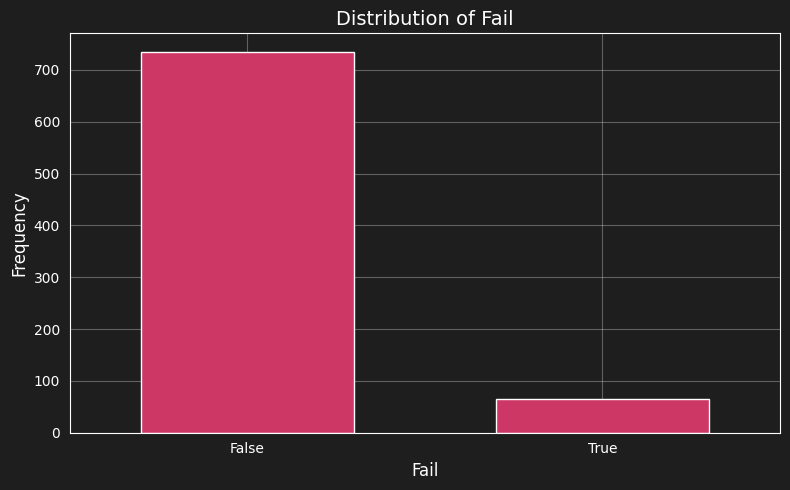

In [10]:
print(df['Fail'].value_counts())
print('\n')
print(df['Fail'].value_counts(normalize=True)*100)

fig = DataPlotter(figsize=(8,5)).plot_histogram(df, 'Fail')

With the above data, it is possible to affirm that the equipment was in a failure state for approximately 8.25% of time or 66 operation cycles. As expected, the target variable is imbalanced, since equipment failure is a relatively rare event. However, the failure state is precisely what needs to be predicted. For this reason, it is essential to understand the equipment’s behavior during failure, despite the smaller amount of available data.

Similarly, it's important to know how many times the equipment failed.

In [11]:
def find_failure_starts(fail_series: pd.Series) -> list:
    """
    Counts the number of times a failure starts (i.e., transitions from False to True) in a boolean Series.

    Args:
        fail_series (pd.Series): A pandas Series of boolean values indicating failure state over time.

    Returns:
        list: List of cycles where transitions from False to True occured.
    """
    # Check if the input series is of boolean dtype
    if fail_series.dtype != bool:
        raise ValueError("Input series must be of boolean dtype.")
    
    # Use shift to 'move' rows one position down and verify previous state
    previous_state = fail_series.shift(1, fill_value=False)

    # Invert previous state to find transitions from False to True
    previous_state = ~previous_state

    # Compare the previous state with the current state to find transitions
    transition_starts = previous_state & fail_series

    return list(transition_starts[transition_starts == True].index)

def find_failure_stops(fail_series: pd.Series) -> list:
    """
    Counts the number of times a failure stops (i.e., transitions from True to False) in a boolean Series.

    Args:
        fail_series (pd.Series): A pandas Series of boolean values indicating failure state over time.

    Returns:
        list: List of cycles where transitions from True to False occured.
    """
    # Check if the input series is of boolean dtype
    if fail_series.dtype != bool:
        raise ValueError("Input series must be of boolean dtype.")
    
    # Use shift to 'move' rows one position down and verify previous state
    previous_state = fail_series.shift(1, fill_value=False)

    # Compare the previous state with the current state to find transitions
    transition_stops = previous_state & ~fail_series

    return list(transition_stops[transition_stops == True].index)


In [12]:
# Find operation cycles where failures start and stop
failures_starts = find_failure_starts(df['Fail'])
failures_stops = find_failure_stops(df['Fail'])

In [13]:
n = len(failures_starts)
failure_duration = df['Fail'].sum()

print(f"Total duration of failure state: {failure_duration} cycles")
print(f"Total number of failure starts: {n}")
print(f"Mean failure state duration per occurence: {failure_duration / n} cycles")

Total duration of failure state: 66 cycles
Total number of failure starts: 10
Mean failure state duration per occurence: 6.6 cycles


Another useful approach is to label each individual failure event. This enables a more detailed analysis of each occurrence in terms of its duration, potential causes, and associated configuration variables. In the following sections, this labeling will allow for a more structured investigation of the equipment’s behavior during each failure episode.

In [19]:
def label_failures(df: pd.DataFrame, target_column: str = 'Fail', fail_index_column: str = 'Fail_index') -> pd.DataFrame:
    """
    Labels the failure periods in the DataFrame with a unique index for each failure.

    Args:
        df (pd.DataFrame): DataFrame containing the failure data with 'Fail' column.

    Returns:
        pd.DataFrame: DataFrame with an additional 'Fail_index' column indicating failure periods.
    """
    # Find start and stop indices of failures
    failures_starts = find_failure_starts(df[target_column])
    failures_stops = find_failure_stops(df[target_column])

    if len(failures_starts) > len(failures_stops):
        failures_stops.append(df.index[-1])  # Append the last index if stops are fewer than starts
    if len(failures_starts) < len(failures_stops):
        failures_starts.append(df.index[0])  # Append the first index if starts are fewer than stops

    # Initialize a new column for failure indices
    df[fail_index_column] = 0

    # Loop through each failure period and assign an index
    for i, (start, stop) in enumerate(zip(failures_starts, failures_stops)):
        print(f"Failure {i+1} start at operation cycle: {start}")
        print(f"Failure {i+1} stop at operation cycle: {stop}")

        # Assigning a failure index to the DataFrame for each failure period
        mask = (df.index >= start) & (df.index <= stop)
        df.loc[mask, 'Fail_index'] = i + 1

    return df

In [20]:
df = label_failures(df, target_column='Fail', fail_index_column='Fail_index')

Failure 1 start at operation cycle: 13
Failure 1 stop at operation cycle: 14
Failure 2 start at operation cycle: 157
Failure 2 stop at operation cycle: 160
Failure 3 start at operation cycle: 163
Failure 3 stop at operation cycle: 166
Failure 4 start at operation cycle: 263
Failure 4 stop at operation cycle: 266
Failure 5 start at operation cycle: 270
Failure 5 stop at operation cycle: 272
Failure 6 start at operation cycle: 415
Failure 6 stop at operation cycle: 433
Failure 7 start at operation cycle: 538
Failure 7 stop at operation cycle: 547
Failure 8 start at operation cycle: 550
Failure 8 stop at operation cycle: 555
Failure 9 start at operation cycle: 700
Failure 9 stop at operation cycle: 714
Failure 10 start at operation cycle: 793
Failure 10 stop at operation cycle: 800


In [40]:
df.head(15)

,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail,Fail_index
Cycle,,,,,,,,,,
1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False,0
2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False,0
3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False,0
4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False,0
5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False,0
6,1,2,58.3361,64.4264,56.4792,78.6237,65.9115,78.8862,False,0
7,1,3,77.9378,83.1467,77.8006,109.6790,86.2307,99.6812,False,0
8,1,4,78.5635,130.0899,110.4799,130.9970,85.2186,98.4674,False,0
9,3,7,77.4862,104.4630,77.3904,159.4235,115.2119,98.9003,False,0


With the new label added to the dataset, it is now possible to identify the failure events that lasted the most operation cycles. These longer events may indicate more critical or severe failures in the equipment.

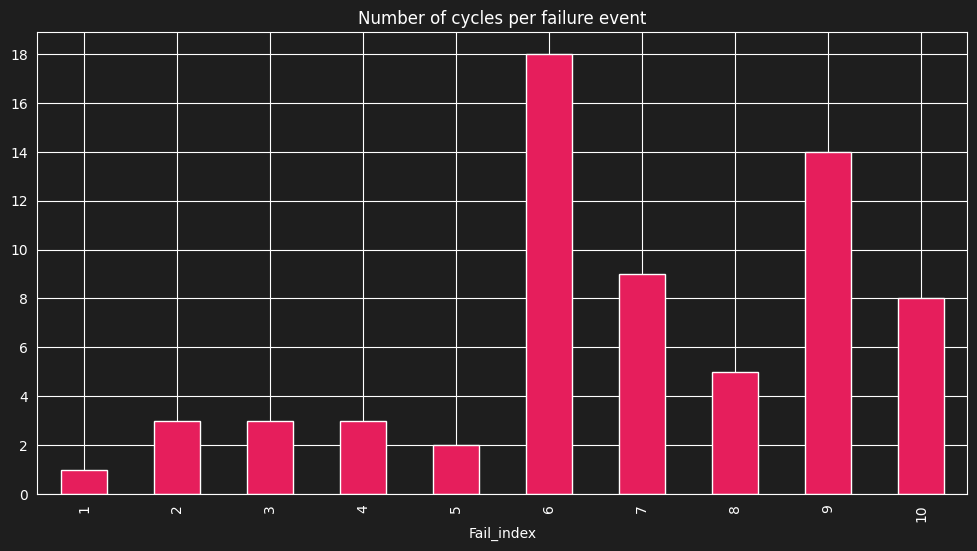

In [ ]:
from matplotlib.ticker import MaxNLocator

failures = df.query('Fail == True').groupby('Fail_index').size()
ax = failures.plot(kind='bar', figsize=(12, 6), title='Number of cycles per failure event')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

In [ ]:
print(f'Total Preset_1 unique_values: {df['Preset_1'].nunique()} - {sorted(df["Preset_1"].unique())}')
print('\n')
print(df['Preset_1'].value_counts())  # Descriptive statistics
print('\n')
print(df['Preset_1'].value_counts(normalize=True))  # Descriptive statistics

In [ ]:
df['Preset_1'].value_counts(normalize=True)  # Descriptive statistics

In [ ]:
df['Fail'].value_counts(normalize=True)  # Descriptive statistics

In [ ]:
df['Preset_2'].value_counts(normalize=True)  # Descriptive statistics